## Examen Restaurantes

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
import plotly.express as px


import ctg_viz
import ctg_viz.plots as plts
import equitLib

### Ingeniería de Datos

In [42]:
users = pd.read_csv('datos/users.csv')
usercuisine = pd.read_csv('datos/usercuisine.csv')
ratings = pd.read_csv('datos/ratings.csv')
restaurants = pd.read_csv('datos/restaurants.csv')
hours = pd.read_csv('datos/hours.csv')
cuisines = pd.read_csv('datos/cuisine.csv')
payment_methods = pd.read_csv('datos/payment_methods.csv')
parking = pd.read_csv('datos/parking.csv')
restaurants.head()


,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,No_Alcohol_Served,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,...,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none
2,135106,22.149709,-100.976093,0101000020957F0000649D6F21634858C119AE9BF528A3...,El Rincón de San Francisco,Universidad 169,San Luis Potosi,San Luis Potosi,Mexico,?,...,Wine-Beer,only at bar,informal,partially,medium,?,familiar,f,open,none
3,132667,23.752697,-99.163359,0101000020957F00005D67BCDDED8157C1222A2DC8D84D...,little pizza Emilio Portes Gil,calle emilio portes gil,victoria,tamaulipas,?,?,...,No_Alcohol_Served,none,informal,completely,low,?,familiar,t,closed,none
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,No_Alcohol_Served,permitted,informal,completely,medium,?,familiar,t,closed,none


### Análisis restaurantes (unidad muestral)

Teniendo en cuenta el dataframe de restaurantes, realizaremos agregaremos variables que aporten valor en los siguientes pasos

In [43]:
#Nuevas variables (meadias de rating, numero de opciones de cocina y pago)
ratings_mean = ratings.groupby('placeID')[['rating','food_rating','service_rating']].mean()
rest_rating = restaurants.join(ratings_mean, on='placeID').rename(columns={'rating':'rating_mean',
                                                                           'food_rating':'food_rating_mean',
                                                                           'service_rating':'service_rating_mean'})
#Número de reseñas
ratings_count = ratings.groupby('placeID')['rating'].count()
rest_rating = rest_rating.join(ratings_count, on='placeID').rename(columns={'rating':'ratings_count'})

#Opciones de cocina
cuisines = cuisines.groupby('placeID')['Rcuisine'].count()
rest_rating = rest_rating.join(cuisines, on='placeID').rename(columns={'Rcuisine':'cuisines_options'})

#Opciones de pago
payment_options = payment_methods.groupby('placeID')['Rpayment'].count()
rest_rating = rest_rating.join(payment_options, on='placeID').rename(columns={'Rpayment': 'payment_options'})

#join con ratings originales
rest_rating = rest_rating.join(ratings.set_index('placeID'), on='placeID')
rest_rating = rest_rating.join(parking.set_index('placeID'), on='placeID')
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,food_rating_mean,service_rating_mean,ratings_count,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1093,2,2,2,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1066,1,1,1,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1040,1,1,1,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1110,2,2,2,none
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.6,1.6,5,1.0,NaN,U1121,2,2,2,none


In [44]:
#Mapear variables categóricas a discretas
rest_rating['price'] = rest_rating.price.map({'low': 1, 'medium': 2, 'high': 3})
rest_rating['franchise'] = rest_rating.franchise.map({'t': 0, 'f': 1})
rest_rating['parking'] = rest_rating.parking_lot.apply(lambda val: 0 if val == 'none' else 1)

#### Target

In [45]:
rest_rating["ratings_count"].mode()

0    4
Name: ratings_count, dtype: int64

Se crea variable target **popular**, para identificar los restaurantes que son más visitados de acuerdo al número de reseñas que tiene, en otras palabras, qué tan visitados son.

In [46]:
#Crear variable target
rest_rating['popular'] = (rest_rating["ratings_count"] > rest_rating["ratings_count"].median()).astype(int)

In [47]:
rest_rating.groupby('placeID')['rating_mean'].mean().mean()

np.float64(1.1796215584942962)

Segunda variable target **good_restaurant**, para identificar si son considerados buenos o malos restaurantes de acuerdo a la media de rating que tienen

In [48]:
# se crea la variable good_restaurant
rest_rating["good_restaurant"] = (rest_rating["rating_mean"] > rest_rating["rating_mean"].mean().mean()).astype(int)
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot,parking,popular,good_restaurant
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1093,2,2,2,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1066,1,1,1,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1040,1,1,1,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1110,2,2,2,none,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,1.0,NaN,U1121,2,2,2,none,0,0,1


In [49]:
rest_rating.groupby(['placeID','name'])['good_restaurant'].count().sort_values(ascending=False).head(10)

placeID  name                              
135085   Tortas Locas Hipocampo                36
132825   puesto de tacos                       32
135032   Cafeteria y Restaurant El Pacifico    28
135052   La Cantina Restaurante                25
132834   Gorditas Doa Gloria                   25
135038   Restaurant la Chalita                 24
135060   Restaurante Marisco Sam               22
135062   Restaurante El Cielo Potosino         21
135042   Restaurant Oriental Express           20
132862   La Posada del Virrey                  18
Name: good_restaurant, dtype: int64

In [50]:
rest_rating[rest_rating['good_restaurant'] == 0].drop_duplicates(['placeID','name']).head()

,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking_lot,parking,popular,good_restaurant
4,132613,23.752903,-99.165076,0101000020957F00008EBA2D06DC8157C194E03B7B504E...,carnitas_mata,lic. Emilio portes gil,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1103,2,2,2,yes,1,0,0
5,135040,22.135617,-100.969709,0101000020957F00001B552189B84A58C15A2AAEFD2CA2...,Restaurant los Compadres,Camino a Simon Diaz 155 Centro,San Luis Potosi,SLP,Mexico,?,...,NaN,3.0,U1126,0,0,0,yes,1,0,0
6,132732,23.754357,-99.171288,0101000020957F00008A20E615808157C16272FECBF84F...,Taqueria EL amigo,Calle Mezquite Fracc Framboyanes,Cd Victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1068,0,0,0,none,0,0,0
7,132875,22.149901,-100.993779,0101000020957F00008A2A0747DE4758C11EB31D2A31A8...,shi ro ie,?,?,?,?,?,...,1.0,5.0,U1047,0,0,0,valet parking,1,0,0
8,132609,23.760268,-99.165865,0101000020957F0000A478418BBA8057C133851EB22C4E...,Pollo_Frito_Buenos_Aires,tampico,victoria,Tamaulipas,Mexico,?,...,1.0,1.0,U1070,1,1,1,yes,1,0,0


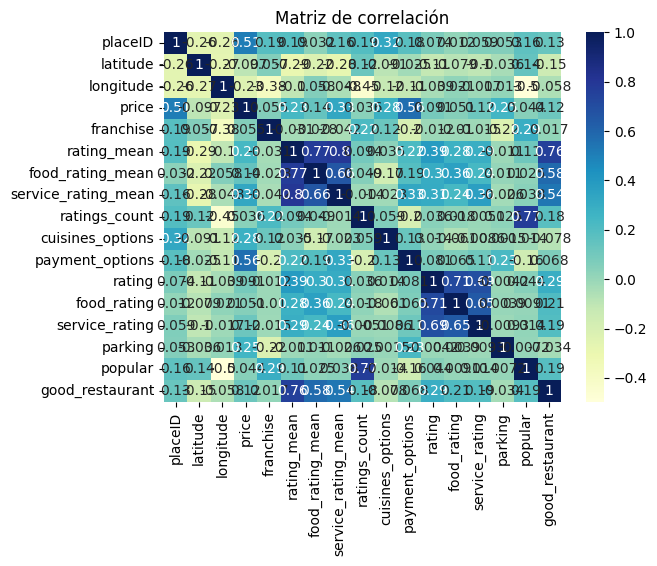

In [51]:
# Matriz de correlación
corr = rest_rating.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="YlGnBu")
plt.title("Matriz de correlación")
plt.show()

### Análisis valores ausentes

Para analizar los valores ausentes del cjto de datos se utilizará la librería **equitLib**, librería que desarrollé como práctica del diplomado

In [52]:
ctgv = ctg_viz.CTGViz(rest_rating)

ctgv.check_data_completeness_dafneelizabethzepedagonzalez()

Como se puede observar, el conjunto se enuentra casi limpio de valores ausentes, a excepción de las variables desarrolladas *cuisines_options* con un 24.81% de faltantes y *payment_options* con un 8.61%.

Para poder imputar las variables correctamente las clasificaremos entre discretas y continuas.

In [53]:
#Categorización de variables
varc, vard = ctgv.vars_categorization()
varc

['placeID',
 'latitude',
 'longitude',
 'rating_mean',
 'food_rating_mean',
 'service_rating_mean',
 'ratings_count']

In [54]:
vard

['the_geom_meter',
 'name',
 'address',
 'city',
 'state',
 'country',
 'fax',
 'zip',
 'alcohol',
 'smoking_area',
 'dress_code',
 'accessibility',
 'price',
 'url',
 'Rambience',
 'franchise',
 'area',
 'other_services',
 'cuisines_options',
 'payment_options',
 'userID',
 'rating',
 'food_rating',
 'service_rating',
 'parking_lot',
 'parking',
 'popular',
 'good_restaurant']

In [55]:
# Imputación de valores faltates para variables discretas por moda
rest_rating['cuisines_options'].fillna(rest_rating['cuisines_options'].mode()[0], inplace=True)
rest_rating['payment_options'].fillna(rest_rating['payment_options'].mode()[0], inplace=True)

## Detección de outliers con Z-score

Utilizaremos la función *outliersz_score* para gráficar, obtener el número de datos que son considerados outliers, al mismo tiempo que los removeremos.

In [56]:
def outliers_zscore(df, column, threshold=3):
    """Detecta outliers por z-score, plotea histograma con umbrales y devuelve filas outliers."""
    if column not in df.select_dtypes(include=[np.number]).columns:
        print(f"Columna {column} no numérica o no existe.")
        return pd.DataFrame()

    s = df[column].dropna()
    if s.empty:
        print(f"No hay datos en {column}.")
        return pd.DataFrame()

    mean, std = s.mean(), s.std()
    if std == 0 or np.isnan(std):
        print(f"Desviación estándar cero/NaN en {column}.")
        return pd.DataFrame()

    z = np.abs((s - mean) / std)
    out_idx = z[z > threshold].index
    outliers = df.loc[out_idx]

    print(f"{column} — outliers: {len(outliers)} / {len(df)} ({len(outliers)/len(df)*100:.2f}%), max z: {z.max():.2f}")

    # Gráfica
    plt.figure(figsize=(8, 4))
    sns.histplot(s, stat="density", color="skyblue", alpha=0.6, label="Datos")
    x = np.linspace(s.min(), s.max(), 200)
    plt.plot(x, norm.pdf(x, mean, std), "k-", lw=1, label="Normal aprox.")
    lower, upper = mean - threshold * std, mean + threshold * std
    plt.axvline(lower, color="red", ls="--", lw=1)
    plt.axvline(upper, color="red", ls="--", lw=1)
    plt.title(f"Outliers Z-score: {column}")
    plt.legend()
    plt.show()

    # Se eliminan los outliers del DataFrame original
    df = df.drop(outliers.index)

placeID — outliers: 0 / 1161 (0.00%), max z: 1.48


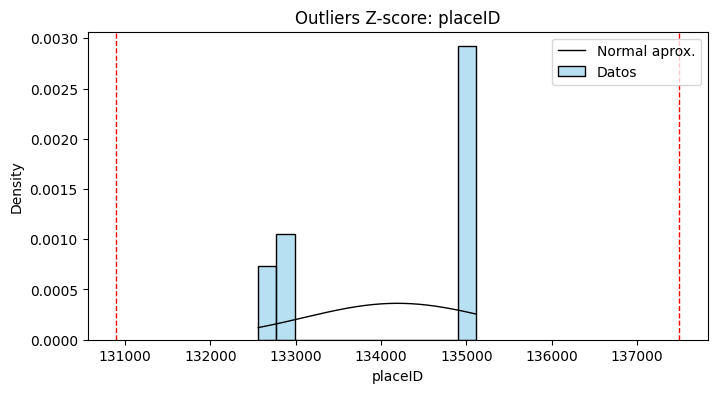

latitude — outliers: 0 / 1161 (0.00%), max z: 2.73


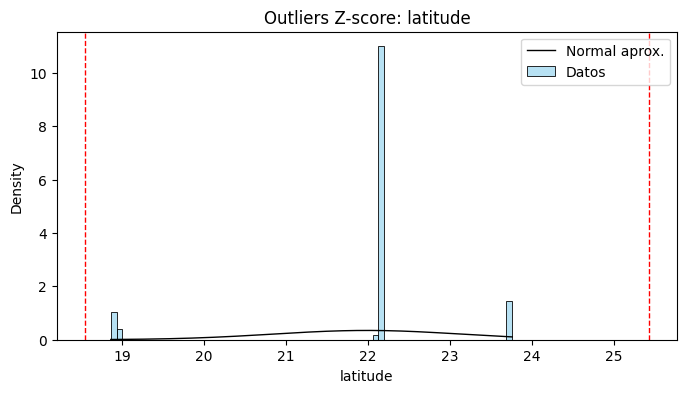

longitude — outliers: 0 / 1161 (0.00%), max z: 2.04


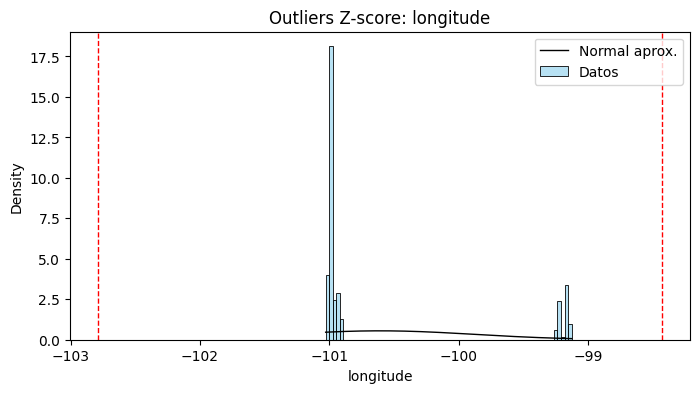

rating_mean — outliers: 32 / 1161 (2.76%), max z: 3.18


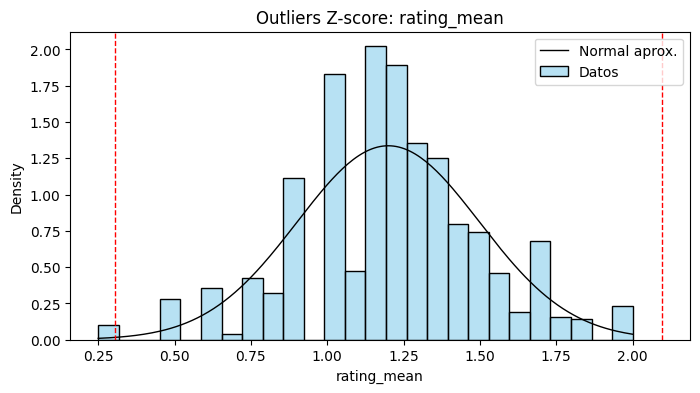

food_rating_mean — outliers: 32 / 1161 (2.76%), max z: 3.37


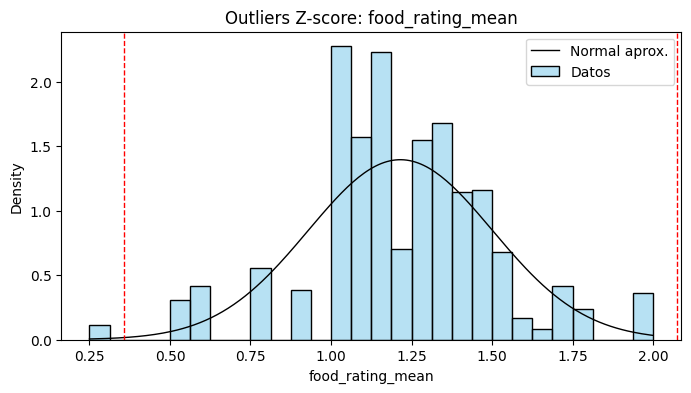

service_rating_mean — outliers: 64 / 1161 (5.51%), max z: 3.17


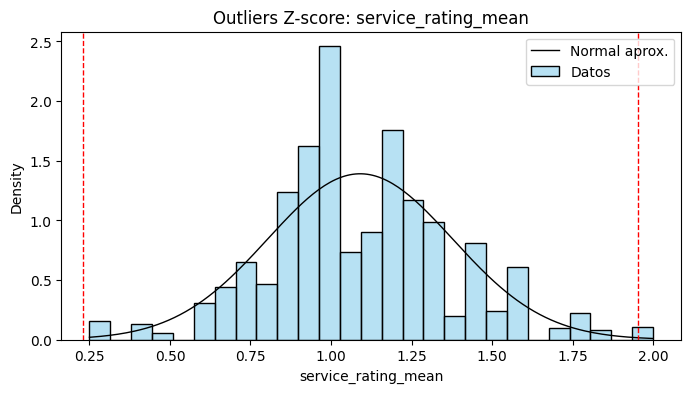

ratings_count — outliers: 0 / 1161 (0.00%), max z: 2.78


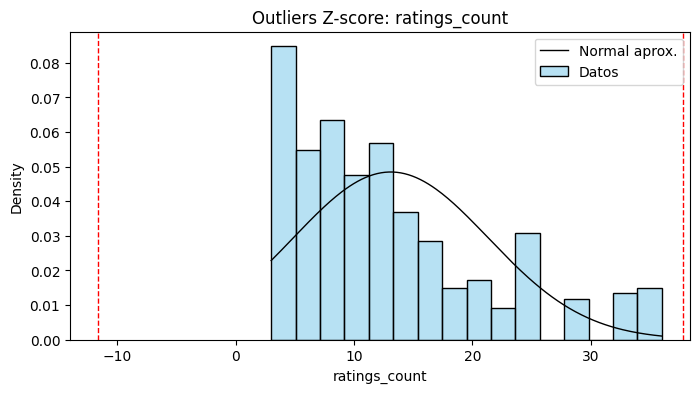

In [57]:
for i in varc:
    outliers_zscore(rest_rating, i, threshold=3)

Se encontraron 32 outliers en *rating_mean*, así como 80 *service_rating_mean* los graficamos nuevamente para comprobar que se eliminaron conrrectamente.

rating_mean — outliers: 32 / 1161 (2.76%), max z: 3.18


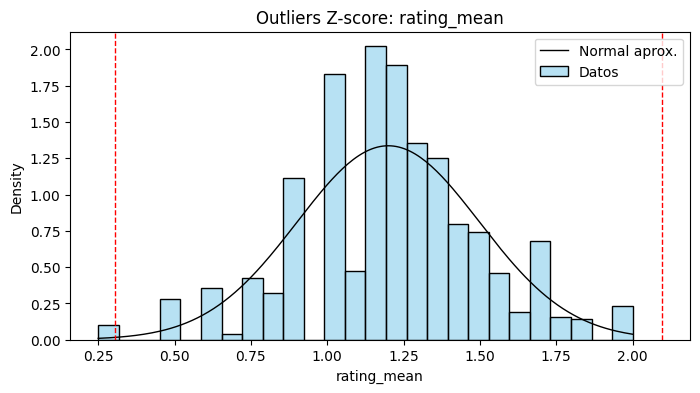

In [58]:
outliers_zscore(rest_rating, 'rating_mean', threshold=3)

service_rating_mean — outliers: 64 / 1161 (5.51%), max z: 3.17


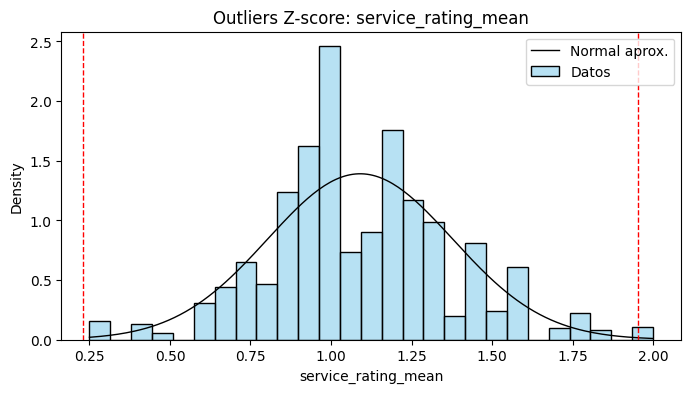

In [59]:
outliers_zscore(rest_rating, 'service_rating_mean', threshold=3)

## Análisis de variables unarias / poco pobladas

In [60]:
plts.histograms.plot_histogram(rest_rating[varc], bins=20)

In [61]:
plts.barplots.plot_barplot(rest_rating[vard])

### Varables Unarias

In [62]:
#Variables unarias
for col in rest_rating.columns:
    if len(rest_rating[col].unique()) == 1:
        print(f"{col}:      {rest_rating[col].unique()[0]}")

fax:      ?


Como podemos obervar, la variable *fax* es unaria, así como las siguientes no cuentan con información relevante o variada, así que procedemos a eliminarlas.

In [63]:
#Se elimina la variable fax y variables poco pobladas o irrelevantes
rest_rating.drop(columns=['fax','country', 'url','other_services','dress_code','address','zip','parking_lot'], inplace=True)


In [64]:
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,city,state,alcohol,smoking_area,accessibility,...,ratings_count,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking,popular,good_restaurant
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1093,2,2,2,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1066,1,1,1,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1040,1,1,1,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1110,2,2,2,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1121,2,2,2,0,0,1


Limpiaremos las variables *City* y *state* para posible uso en el futuro

In [65]:
rest_rating['city'] = rest_rating['city'].replace({'s.l.p.': 'San Luis Potosí',
                                                   'san luis potosi': 'San Luis Potosí',
                                                   'slp': 'San Luis Potosí',
                                                   'San Luis Potosi': 'San Luis Potosí',
                                                   's.l.p. ': 'San Luis Potosí',
                                                   's.l.p': 'San Luis Potosí',
                                                   'san luis potos': 'San Luis Potosí',
                                                   'san luis potosi ': 'San Luis Potosí',
                                                   'cuernavaca': 'Cuernavaca',
                                                   'victoria': 'Ciudad Victoria',
                                                   'victoria ': 'Ciudad Victoria',
                                                   'Cd Victoria': 'Ciudad Victoria',
                                                   'Cd. Victoria': 'Ciudad Victoria',
                                                   '?': 'Desconocida'})
rest_rating['city'].value_counts()

city
San Luis Potosí    834
Desconocida        114
Cuernavaca          89
Ciudad Victoria     88
Jiutepec            19
Soledad             17
Name: count, dtype: int64

In [66]:
rest_rating['state'] = rest_rating['state'].replace({'morelos': 'Morelos',
                                                     'SLP': 'San Luis Potosí',
                                                     'San Luis Potosi': 'San Luis Potosí',
                                                     'san luis potosi': 'San Luis Potosí',
                                                     's.l.p.': 'San Luis Potosí',
                                                     'S.L.P.': 'San Luis Potosí',
                                                     'slp': 'San Luis Potosí',
                                                     'san luis potos': 'San Luis Potosí',
                                                     'tamaulipas': 'Tamaulipas',
                                                     'mexico': 'México',
                                                     '?': 'Desconocido'})
rest_rating.state.value_counts()

state
San Luis Potosí    835
Desconocido        113
Morelos            108
Tamaulipas          88
México              17
Name: count, dtype: int64

In [67]:
varc, vard = ctgv.vars_categorization()
vard

['the_geom_meter',
 'name',
 'city',
 'state',
 'alcohol',
 'smoking_area',
 'accessibility',
 'price',
 'Rambience',
 'franchise',
 'area',
 'cuisines_options',
 'payment_options',
 'userID',
 'rating',
 'food_rating',
 'service_rating',
 'parking',
 'popular',
 'good_restaurant']

## Correlación de variables

In [68]:
plts.heatmap.plot_heatmap(rest_rating)

En graficar la matriz de correlación no detectamos alguna con 1 de correlación así que no eliminamos ninguna.

### Reducción de dimensiones

In [69]:
features = ['food_rating',
    'service_rating',
    'food_rating_mean',
    'service_rating_mean',
    'rating',
    'rating_mean',
    'ratings_count',
    'cuisines_options',
    'payment_options',
    'price',
    'franchise',
    'parking']

In [70]:
rest_rating.head()

,placeID,latitude,longitude,the_geom_meter,name,city,state,alcohol,smoking_area,accessibility,...,ratings_count,cuisines_options,payment_options,userID,rating,food_rating,service_rating,parking,popular,good_restaurant
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1093,2,2,2,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1066,1,1,1,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1040,1,1,1,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1110,2,2,2,0,0,1
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Cuernavaca,Morelos,No_Alcohol_Served,none,no_accessibility,...,5,1.0,1.0,U1121,2,2,2,0,0,1


In [71]:
df_pca, modelo_pca = equitLib.aplicar_pca(rest_rating[features], n_components=2)
equitLib.resumen_componentes(modelo_pca, features
, n_top=3)

df_plot = pd.concat([df_pca, rest_rating[['popular']].reset_index(drop=True)], axis=1)

fig = px.scatter(
    df_pca, 
    x='PC1', 
    y='PC2', 
    color='PC1',          
    color_continuous_scale='RdBu', 
    opacity=0.5,               
    title='PCA 2D: Distribución de Riesgo'
)
fig.update_layout(template='plotly_dark')
fig.show()

Varianza explicada: [0.29316426 0.1523123 ]
--- Resumen: Variables más influyentes por Componente ---

Componente Principal 1 (PC1):
   - rating_mean: 0.4301
   - service_rating_mean: 0.4200
   - food_rating_mean: 0.3977

Componente Principal 2 (PC2):
   - payment_options: 0.5135
   - price: 0.4651
   - parking: 0.3649


Encontramos por medio de PCA los mejores 2 componentes para redimencionar el conjunto.

### Select K-Best

In [72]:
### SelectKBest 
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import KBinsDiscretizer, MinMaxScaler

### Cambiar por Variable Objetivo
X = rest_rating.drop(columns=['popular'])
y = rest_rating['popular']

### Selecionamos columnas numericas
num_vars = X.select_dtypes(include=['int64','int32','int16', 'float64','float32','float16']).columns
X_num = X[num_vars]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_num)
### Discretizamos las varibales numericas
kbd = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_discretizada = kbd.fit_transform(X_scaled)

selector = SelectKBest(score_func=chi2, k=7)
X_new = selector.fit_transform(X_discretizada, y)

selected_features = num_vars[selector.get_support()]

print(f'Las variables seleccionadas son: {selected_features}')

Las variables seleccionadas son: Index(['placeID', 'latitude', 'longitude', 'franchise', 'ratings_count',
       'payment_options', 'good_restaurant'],
      dtype='object')


Mediante Select K-Best se encintró que las feautes con mayor relación con la taget popular son: latitude, longitude, franchise, ratings_count, payment_options y good_restaurant.

### Mejores variables utilizando WoE y IV

In [73]:
woe, iv = equitLib.calcular_woe_iv(rest_rating, target='popular')
iv.head()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log



,variable,IV
0,the_geom_meter,inf
1,name,inf
2,city,inf
3,state,inf
5,smoking_area,inf


In [74]:
### eliminacion de las variables 
umbral_iv = 0.02
variables_seleccionadas = iv[iv['IV'] <= umbral_iv]['variable'].tolist()
### Eliminamos las columnas categoricas con bajo nivel predictivo del df
rest_rating.drop(columns=variables_seleccionadas,inplace=True)


variables_seleccionadas

['area', 'Rambience']

In [75]:
rest_rating.columns

Index(['placeID', 'latitude', 'longitude', 'the_geom_meter', 'name', 'city',
       'state', 'alcohol', 'smoking_area', 'accessibility', 'price',
       'franchise', 'rating_mean', 'food_rating_mean', 'service_rating_mean',
       'ratings_count', 'cuisines_options', 'payment_options', 'userID',
       'rating', 'food_rating', 'service_rating', 'parking', 'popular',
       'good_restaurant'],
      dtype='object')

In [77]:
#guardamos el dataset limpio
rest_rating.to_csv('datos/restaurants_cleaned.csv', index=False)